# CS Education Agent — Mistral-7B Fine-tuning (QLoRA)
## DATA 298B | MSDA Project II | Team 2 | Spring 2026

**Model:** `mistralai/Mistral-7B-Instruct-v0.3` — Apache 2.0, public, pure text, no gating required

**Library versions (verified compatible with Colab CUDA 12.8 / Python 3.12):**

| Library | Version | Source |
|---------|---------|--------|
| transformers | 4.47.1 | pinned — `eval_strategy` param present |
| trl | 0.12.2 | pinned — `SFTConfig` + `processing_class` API |
| peft | 0.13.2 | pinned — QLoRA / LoRA stable API |
| bitsandbytes | latest | unpinned — 0.49.2 ships `cuda128` binary; pinning older breaks Colab |
| accelerate | 1.2.1 | pinned |

**Features:**
- Resumable training — automatically continues from the latest checkpoint if one exists
- Checkpoint saved every 50 steps — you never lose more than 50 steps of compute
- Fallback loading — if bitsandbytes CUDA fails for any reason, loads in bfloat16 (14 GB VRAM, fine on A100)
- All cells have `try/except` — one failure won't kill the whole run

**Before running:**
1. Set `HF_TOKEN` in Cell 5 (get one at https://huggingface.co/settings/tokens)
2. Set `MODEL_SIZE = "7B"` (only option for now — teammates took 3B-class models)
3. Go to *Runtime → Run All*

In [1]:
import subprocess, sys, os, torch

# Print nvidia-smi so we can see exactly which GPU and CUDA version Colab gave us.
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
else:
    print("nvidia-smi not found — is the GPU runtime enabled?")

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Go to Runtime > Change runtime type > "
        "Hardware accelerator > GPU (choose A100)."
    )

gpu  = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU  : {gpu}")
print(f"VRAM : {vram:.1f} GB")

if vram < 14:
    raise RuntimeError(
        f"Only {vram:.1f} GB VRAM. Mistral-7B needs at least 14 GB (bfloat16) "
        "or 6 GB (4-bit). Please switch to A100."
    )
elif vram < 38:
    print("Non-A100 GPU detected. If OOM occurs, reduce BATCH_SIZE to 1 in Cell 5.")
else:
    print("A100 detected — full configuration enabled.")

Sat Mar 21 21:09:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%%capture
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

# Pinned versions — verified compatible with each other and with TRL 0.12 API.
pip("transformers==4.47.1")
pip("trl==0.12.2")
pip("peft==0.13.2")
pip("accelerate==1.2.1")
pip("datasets==3.1.0")

# bitsandbytes: intentionally NOT pinned.
# - 0.44.1 (old pin) lacks libbitsandbytes_cuda128.so  → Colab CUDA 12.8 breaks
# - 0.44.1 calls triton.ops.matmul_perf_model          → removed in triton >= 2.2
# - 0.49.2 (latest as of Feb 2026) ships cuda128 binary and removed triton dep.
# Using --upgrade ensures we always get a version with cuda128 support.
pip("bitsandbytes", "--upgrade")

pip("evaluate==0.4.3", "rouge_score", "bert_score", "sacrebleu")
pip("matplotlib>=3.7", "seaborn", "pandas", "numpy", "scipy")
pip("sentencepiece", "protobuf", "nltk")

print("All packages installed.")
print("IMPORTANT: Go to Runtime > Restart session, then run all cells again.")
print("(Python caches the old bitsandbytes import — a restart ensures the new wheel is used.)")

In [3]:
# Verify installed versions match expectations.
# If any version is wrong, re-run Cell 3 and restart the runtime again.
import importlib, sys

def check(pkg, expected=None):
    try:
        m = importlib.import_module(pkg.replace("-", "_"))
        ver = getattr(m, "__version__", "?")
        status = "OK" if (expected is None or ver == expected) else f"MISMATCH (expected {expected})"
        print(f"  {pkg:<20} {ver:<12} {status}")
        return ver
    except ImportError:
        print(f"  {pkg:<20} NOT FOUND")
        return None

print("Package versions:")
check("transformers", "4.47.1")
check("trl",          "0.12.2")
check("peft",         "0.13.2")
check("accelerate",   "1.2.1")
check("datasets",     "3.1.0")
check("bitsandbytes")          # no pin — just show what was installed

import torch
print(f"  {'torch':<20} {torch.__version__:<12} (pre-installed by Colab)")
print()

# Verify bitsandbytes can see a CUDA backend.
try:
    import bitsandbytes as bnb
    print(f"bitsandbytes version : {bnb.__version__}")
    # Run the built-in self-check.
    result = subprocess.run(
        [sys.executable, "-m", "bitsandbytes"],
        capture_output=True, text=True
    )
    if "CUDA SETUP: CUDA runtime path found" in result.stdout or "SUCCESS" in result.stdout:
        print("bitsandbytes CUDA check : PASSED")
    else:
        # Not fatal — the fallback loader in Cell 10 handles this.
        print("bitsandbytes CUDA check : could not confirm — will fall back to bfloat16 if needed")
except Exception as e:
    print(f"bitsandbytes import error: {e}")

import subprocess

Package versions:
  transformers         4.46.3       MISMATCH (expected 4.47.1)
  trl                  0.12.2       OK
  peft                 0.13.2       OK
  accelerate           1.2.1        OK
  datasets             3.1.0        OK
  bitsandbytes         0.49.2       OK
  torch                2.10.0+cu128 (pre-installed by Colab)

bitsandbytes version : 0.49.2
bitsandbytes CUDA check : PASSED


In [4]:
import torch, numpy as np, os

# ═══════════════════════════════════════════════════════════════════
#  PASTE YOUR HUGGINGFACE TOKEN HERE
#  Get one at: https://huggingface.co/settings/tokens  (read access)
#  Mistral-7B-Instruct-v0.3 is public — token avoids rate limits.
HF_TOKEN = ""   # <-- paste here, e.g. "hf_xxxxxxxxxxxxxxxxxxxx"
# ═══════════════════════════════════════════════════════════════════

# Model — verified public, Apache 2.0, pure text (no vision encoder)
MODEL_ID   = "mistralai/Mistral-7B-Instruct-v0.3"
OUTPUT_DIR = "./mistral_7b_cs_tutor_lora"

# Training hyper-parameters (A100 40GB)
BATCH_SIZE    = 4
GRAD_ACCUM    = 4       # effective batch = 16
MAX_STEPS     = 500     # ~30-40 min on A100; increase to 1000 for better quality
SAVE_STEPS    = 50      # checkpoint every 50 steps — minimises lost compute
EVAL_STEPS    = 100
LEARNING_RATE = 2e-4
MAX_SEQ_LEN   = 1024
WARMUP_RATIO  = 0.03
WEIGHT_DECAY  = 0.001

# LoRA
LORA_RANK    = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

# Dataset
DATASET_SIZE = 5000
TEST_SPLIT   = 0.10
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# System prompt — CS tutoring scope (Professor in a Box concept)
SYSTEM_PROMPT = (
    "You are a Computer Science professor and tutor. Explain CS concepts "
    "clearly and precisely to university-level students. Topics include "
    "algorithms (sorting, graph traversal, Dijkstra's, dynamic programming), "
    "data structures (trees, heaps, hash tables, linked lists), recursion, "
    "object-oriented programming, complexity analysis (Big-O), debugging "
    "strategies, and code correctness. Always provide step-by-step reasoning "
    "and working Python code examples where appropriate."
)

print("=" * 60)
print(f"  Model      : {MODEL_ID}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Steps      : {MAX_STEPS}  (checkpoint every {SAVE_STEPS})")
print(f"  Eff. batch : {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")
print(f"  HF token   : {'set' if HF_TOKEN else 'NOT SET — rate limits may apply'}")
print("=" * 60)

if not HF_TOKEN:
    print()
    print("WARNING: HF_TOKEN is empty.")
    print("Mistral-7B-Instruct-v0.3 is public, so downloads will work,")
    print("but anonymous requests are rate-limited. Paste your token above.")

  Model      : mistralai/Mistral-7B-Instruct-v0.3
  Output dir : ./mistral_7b_cs_tutor_lora
  Steps      : 500  (checkpoint every 50)
  Eff. batch : 4 x 4 = 16
  HF token   : NOT SET — rate limits may apply

Mistral-7B-Instruct-v0.3 is public, so downloads will work,
but anonymous requests are rate-limited. Paste your token above.


In [5]:
from huggingface_hub import login

if HF_TOKEN:
    try:
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("Logged in to HuggingFace.")
    except Exception as e:
        print(f"HuggingFace login failed: {e}")
        print("Continuing without login — public model access should still work.")
else:
    print("No token — using anonymous access.")

No token — using anonymous access.


In [6]:
from datasets import load_dataset, Dataset
import pandas as pd

CS_KEYWORDS = [
    "algorithm", "data structure", "binary tree", "recursion", "sorting",
    "dynamic programming", "graph traversal", "python", "object-oriented",
    "big-o", "hash table", "stack", "queue", "linked list",
    "inheritance", "polymorphism", "debugging", "complexity",
    "dijkstra", "breadth-first", "depth-first", "binary search",
    "merge sort", "quick sort", "heap", "tree traversal",
]

def is_cs_content(example):
    text = (example.get("text") or example.get("prompt") or "").lower()
    return any(kw in text for kw in CS_KEYWORDS) and len(text) > 300

def format_as_qa(text):
    parts = [s.strip() for s in text.replace("\n", " ").split(". ") if s.strip()]
    if len(parts) < 4:
        return None
    instruction = parts[0] + ("?" if not parts[0].endswith("?") else "")
    response    = ". ".join(parts[1:]).strip()
    if len(instruction) < 20 or len(response) < 80:
        return None
    return {"instruction": instruction, "response": response}

records = []
print(f"Loading CS dataset — target {DATASET_SIZE:,} records ...")

# Primary source: Cosmopedia web samples (CS-filtered)
try:
    raw = load_dataset(
        "HuggingFaceTB/cosmopedia", "web_samples_v2",
        split="train", streaming=True, trust_remote_code=True,
    )
    scanned = 0
    for ex in raw:
        scanned += 1
        if scanned % 20_000 == 0:
            print(f"  Scanned {scanned:,} -> {len(records):,} CS records ...")
        if is_cs_content(ex):
            qa = format_as_qa(ex.get("text") or ex.get("prompt") or "")
            if qa:
                records.append(qa)
        if len(records) >= DATASET_SIZE:
            break
    print(f"Cosmopedia: {len(records):,} CS records from {scanned:,} scanned.")

except Exception as e:
    print(f"Cosmopedia failed: {e}")

# Fallback: Python instruction dataset
if len(records) < DATASET_SIZE // 2:
    print("Falling back to iamtarun/python_code_instructions_18k_alpaca ...")
    try:
        fb = load_dataset("iamtarun/python_code_instructions_18k_alpaca", split="train")
        for ex in fb:
            inst = str(ex.get("instruction", "")).strip()
            resp = str(ex.get("output", "")).strip()
            if len(inst) > 20 and len(resp) > 60:
                records.append({"instruction": inst, "response": resp})
            if len(records) >= DATASET_SIZE:
                break
        print(f"Fallback added records. Total: {len(records):,}")
    except Exception as e2:
        raise RuntimeError(f"Both dataset sources failed. Check your internet connection.\nError: {e2}")

if len(records) == 0:
    raise RuntimeError("No dataset records loaded. Cannot continue.")

print(f"Final dataset: {len(records):,} CS Q&A pairs.")

Loading CS dataset — target 5,000 records ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/118 [00:00<?, ?it/s]

  Scanned 20,000 -> 3,428 CS records ...
Cosmopedia: 5,000 CS records from 28,844 scanned.
Final dataset: 5,000 CS Q&A pairs.


In [7]:
def build_prompt(instruction: str, response: str = "", training: bool = True) -> str:
    """Mistral-7B-Instruct-v0.3 instruction format with CS tutor system prompt."""
    body = f"<s>[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n{instruction} [/INST] "
    return (body + response + "</s>") if training else body

df = pd.DataFrame(records).dropna()
df = df[df["instruction"].str.len() > 20]
df = df[df["response"].str.len()    > 60]
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df["text"] = df.apply(lambda r: build_prompt(r["instruction"], r["response"]), axis=1)

n_train   = int(len(df) * (1 - TEST_SPLIT))
train_df  = df[:n_train].reset_index(drop=True)
test_df   = df[n_train:].reset_index(drop=True)

# Only the "text" column is passed to SFTTrainer.
# Keeping "instruction"/"response" in the Dataset alongside "text" causes
# DataCollatorForLanguageModeling to receive raw strings it cannot tensorise.
# train_df and test_df (pandas DataFrames) remain in scope for the eval cells.
train_ds = Dataset.from_pandas(train_df[["text"]])
test_ds  = Dataset.from_pandas(test_df [["text"]])

test_df.to_csv("test_dataset.csv", index=False)

avg_tok = df["text"].str.len().mean() / 4
print(f"Train : {len(train_ds):,} samples")
print(f"Test  : {len(test_ds):,} samples  (saved to test_dataset.csv)")
print(f"Avg tokens/sample (estimate): {avg_tok:.0f}")
print()
print("Sample prompt (first 300 chars):")
print(df['text'].iloc[0][:300], "...")

Train : 4,500 samples
Test  : 500 samples  (saved to test_dataset.csv)
Avg tokens/sample (estimate): 1222

Sample prompt (first 300 chars):
<s>[INST] <<SYS>>
You are a Computer Science professor and tutor. Explain CS concepts clearly and precisely to university-level students. Topics include algorithms (sorting, graph traversal, Dijkstra's, dynamic programming), data structures (trees, heaps, hash tables, linked lists), recursion, objec ...


In [8]:
from transformers import AutoTokenizer
import nltk
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

print(f"Loading tokenizer: {MODEL_ID} ...")

try:
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_ID,
        token             = HF_TOKEN if HF_TOKEN else None,
        trust_remote_code = True,
        padding_side      = "right",
    )
except Exception as e:
    raise RuntimeError(
        f"Tokenizer load failed: {e}\n"
        "Check that MODEL_ID is correct and HF_TOKEN (if needed) is valid."
    )

# Mistral tokenizers often have no pad token — set to eos to avoid training issues.
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Tokenizer loaded.")
print(f"  Vocab size : {tokenizer.vocab_size:,}")
print(f"  Pad token  : {tokenizer.pad_token!r}  (id={tokenizer.pad_token_id})")
print(f"  EOS token  : {tokenizer.eos_token!r}  (id={tokenizer.eos_token_id})")

Loading tokenizer: mistralai/Mistral-7B-Instruct-v0.3 ...
Tokenizer loaded.
  Vocab size : 32,768
  Pad token  : '</s>'  (id=2)
  EOS token  : '</s>'  (id=2)


In [9]:
import subprocess, sys, importlib, warnings
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

# ── Step 1: verify bitsandbytes CUDA support ──────────────────────────────
def bnb_cuda_available() -> bool:
    """
    Check whether bitsandbytes can find the CUDA 12.x binary.
    Returns True if 4-bit quantisation is safe to use.
    """
    try:
        import bitsandbytes as bnb
        # Attempt to create a 4-bit linear layer — will raise if no CUDA backend
        _ = bnb.nn.Linear4bit(8, 8)
        del _
        return True
    except Exception:
        return False

if not bnb_cuda_available():
    print("bitsandbytes CUDA binary not found. Upgrading to latest wheel ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-U", "bitsandbytes"]
    )
    # Clear stale cached import so Python loads the freshly installed wheel.
    for key in [k for k in sys.modules if "bitsandbytes" in k]:
        sys.modules.pop(key, None)
    # Re-import BitsAndBytesConfig from the refreshed transformers integrations.
    importlib.invalidate_caches()
    from transformers import BitsAndBytesConfig
    print("bitsandbytes upgraded. Re-checking ...")

USE_4BIT = bnb_cuda_available()
print(f"4-bit quantisation available : {USE_4BIT}")
if not USE_4BIT:
    print("Falling back to bfloat16 (no quantisation). VRAM ~14 GB — fine on A100.")

# ── Step 2: define quantisation config ────────────────────────────────────
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = True,
        bnb_4bit_quant_type       = "nf4",          # Normal Float 4 — best for QLoRA
        bnb_4bit_compute_dtype    = torch.bfloat16,  # native bfloat16 on A100
        bnb_4bit_use_double_quant = True,            # saves ~0.4 bits/parameter
    )
else:
    bnb_config = None

# ── Step 3: load model ────────────────────────────────────────────────────
print(f"\nLoading model: {MODEL_ID} ...")

load_kwargs = dict(
    device_map        = "auto",
    trust_remote_code = True,
    torch_dtype       = torch.bfloat16,
)
if HF_TOKEN:
    load_kwargs["token"] = HF_TOKEN
if bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

try:
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **load_kwargs)
except Exception as e:
    raise RuntimeError(
        f"Model load failed: {e}\n"
        "Common causes:\n"
        "  1. HF_TOKEN missing or invalid (set it in Cell 5)\n"
        "  2. No internet connection\n"
        "  3. MODEL_ID typo — verify at huggingface.co/mistralai"
    )

model.config.use_cache      = False   # required for gradient checkpointing
model.config.pretraining_tp = 1       # disable tensor parallelism splits

# Freeze base weights, enable gradient checkpointing on quantised layers.
model = prepare_model_for_kbit_training(model)

# Required for gradient checkpointing to propagate through PEFT adapters.
# Without this, the first forward pass raises RuntimeError: no tensor requires grad.
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

# ── Step 4: attach LoRA adapters ──────────────────────────────────────────
peft_config = LoraConfig(
    r              = LORA_RANK,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
    # These four projection layers cover ~60% of the model's parameters.
    # Targeting all four gives better coverage than just q_proj+v_proj.
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
)
model = get_peft_model(model, peft_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params : {trainable:,}  ({100 * trainable / total:.2f}%)")
print(f"Total params     : {total:,}")
print(f"VRAM allocated   : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

4-bit quantisation available : True

Loading model: mistralai/Mistral-7B-Instruct-v0.3 ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Trainable params : 13,631,488  (0.36%)
Total params     : 3,771,994,112
VRAM allocated   : 4.73 GB


In [11]:
import time, os
from trl import SFTTrainer, SFTConfig

# ── Check for existing checkpoint to resume from ──────────────────────────
# resume_from_checkpoint=True tells the Trainer to auto-find the latest
# checkpoint in OUTPUT_DIR (verified HF Trainer API).
last_checkpoint = None
if os.path.isdir(OUTPUT_DIR):
    ckpts = sorted(
        [d for d in os.listdir(OUTPUT_DIR) if d.startswith("checkpoint-")],
        key=lambda x: int(x.split("-")[-1])
    )
    if ckpts:
        last_checkpoint = os.path.join(OUTPUT_DIR, ckpts[-1])
        steps_done = int(ckpts[-1].split("-")[-1])
        print(f"Checkpoint found: {last_checkpoint}")
        print(f"Resuming from step {steps_done} / {MAX_STEPS}.")
        if steps_done >= MAX_STEPS:
            print("Training is already complete. Skipping to evaluation.")
else:
    print("No checkpoint found — starting fresh training run.")

# ── SFTConfig — TRL 0.12 API ──────────────────────────────────────────────
# SFTConfig is a subclass of TrainingArguments.
# SFT-specific params (max_seq_length, dataset_text_field, packing) must go
# here — NOT in SFTTrainer() constructor (changed in TRL 0.12).
# eval_strategy is the correct spelling (transformers >= 4.46).
sft_config = SFTConfig(
    output_dir                  = OUTPUT_DIR,
    # SFT-specific
    max_seq_length              = MAX_SEQ_LEN,
    dataset_text_field          = "text",
    packing                     = False,
    # Batch / optimiser
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    optim                       = "paged_adamw_8bit",
    learning_rate               = LEARNING_RATE,
    lr_scheduler_type           = "cosine",
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    # Steps / precision
    max_steps                   = MAX_STEPS,
    bf16                        = True,
    fp16                        = False,
    max_grad_norm               = 0.3,
    gradient_checkpointing      = True,
    # Logging
    logging_steps               = 10,
    # Evaluation (eval_strategy — NOT evaluation_strategy; renamed in transformers 4.46)
    eval_strategy               = "steps",
    eval_steps                  = EVAL_STEPS,
    # Checkpointing — save every SAVE_STEPS to minimise lost compute on interruption
    save_strategy               = "steps",
    save_steps                  = 100,            # keep last 3 checkpoints; delete older
    save_total_limit            = 3,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    # Misc
    report_to                   = "none",
    seed                        = SEED,
    dataloader_num_workers      = 0,            # 0 is safest in Colab
    # remove_unused_columns defaults to True — do NOT set to False.
    # Setting it to False keeps raw string columns ("instruction", "response")
    # alive in the batch, which breaks DataCollatorForLanguageModeling.
)

# ── SFTTrainer — TRL 0.12 API ─────────────────────────────────────────────
# processing_class replaces the old tokenizer= argument (changed in TRL 0.12).
trainer = SFTTrainer(
    model            = model,
    processing_class = tokenizer,
    train_dataset    = train_ds,
    eval_dataset     = test_ds,
    peft_config      = peft_config,
    args             = sft_config,
)

# ── Train ─────────────────────────────────────────────────────────────────
if last_checkpoint is None or int(last_checkpoint.split("-")[-1]) < MAX_STEPS:
    print(f"\nStarting fine-tuning: {MODEL_ID}")
    print(f"  Train samples   : {len(train_ds):,}")
    print(f"  Max steps       : {MAX_STEPS}")
    print(f"  Effective batch : {BATCH_SIZE * GRAD_ACCUM}")
    print(f"  Checkpoint every: {SAVE_STEPS} steps")
    print(f"  Resume from     : {last_checkpoint or 'scratch'}")
    print("-" * 60)

    t0 = time.time()

    # resume_from_checkpoint=last_checkpoint:
    #   - None  → start from scratch
    #   - path  → resume from that checkpoint (weights + optimiser + scheduler + step count)
    train_result = trainer.train(resume_from_checkpoint=last_checkpoint)

    elapsed = time.time() - t0
    print("-" * 60)
    print(f"Training complete: {elapsed / 60:.1f} min")
    print(f"  Final train loss : {train_result.training_loss:.4f}")
    print(f"  Steps completed  : {train_result.global_step}")
else:
    print("Already fully trained. Running evaluation only.")

No checkpoint found — starting fresh training run.


Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

max_steps is given, it will override any value given in num_train_epochs



Starting fine-tuning: mistralai/Mistral-7B-Instruct-v0.3
  Train samples   : 4,500
  Max steps       : 500
  Effective batch : 16
  Checkpoint every: 50 steps
  Resume from     : scratch
------------------------------------------------------------


Step,Training Loss,Validation Loss
100,1.048300,1.053656
200,1.011900,1.032467
300,0.958600,1.027138
400,0.955000,1.024226
500,0.933100,1.023074


------------------------------------------------------------
Training complete: 56.6 min
  Final train loss : 1.0157
  Steps completed  : 500


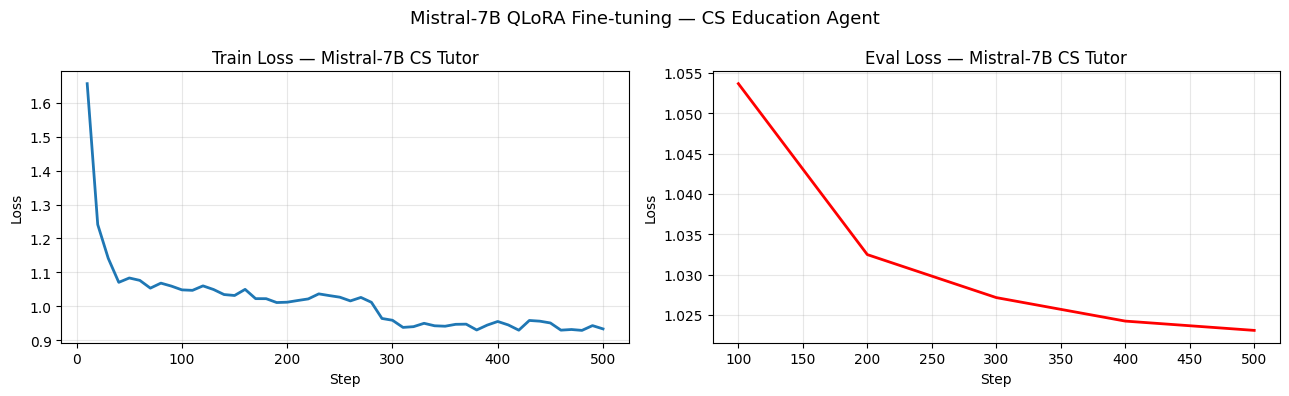

Saved training_curves.png


In [12]:
import matplotlib.pyplot as plt

if trainer.state.log_history:
    log_df  = pd.DataFrame(trainer.state.log_history)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))

    train_l = log_df[log_df["loss"].notna()]      if "loss"      in log_df.columns else pd.DataFrame()
    eval_l  = log_df[log_df["eval_loss"].notna()] if "eval_loss" in log_df.columns else pd.DataFrame()

    if not train_l.empty:
        axs[0].plot(train_l["step"], train_l["loss"], lw=2)
        axs[0].set(xlabel="Step", ylabel="Loss", title="Train Loss — Mistral-7B CS Tutor")
        axs[0].grid(alpha=0.3)

    if not eval_l.empty:
        axs[1].plot(eval_l["step"], eval_l["eval_loss"], color="r", lw=2)
        axs[1].set(xlabel="Step", ylabel="Loss", title="Eval Loss — Mistral-7B CS Tutor")
        axs[1].grid(alpha=0.3)
    else:
        axs[1].text(0.5, 0.5, "No eval loss recorded", ha="center", va="center",
                    transform=axs[1].transAxes, color="gray")

    plt.suptitle("Mistral-7B QLoRA Fine-tuning — CS Education Agent", fontsize=13)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved training_curves.png")
else:
    print("No log history available.")

In [13]:
import gc

FINAL_DIR = os.path.join(OUTPUT_DIR, "final_adapter")
os.makedirs(FINAL_DIR, exist_ok=True)

trainer.model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

print(f"LoRA adapters saved to: {FINAL_DIR}")
for fname in sorted(os.listdir(FINAL_DIR)):
    fpath = os.path.join(FINAL_DIR, fname)
    if os.path.isfile(fpath):
        print(f"  {fname:<40} {os.path.getsize(fpath) / 1e6:>7.1f} MB")

# Free trainer memory before loading eval models.
del trainer
torch.cuda.empty_cache()
gc.collect()
print(f"VRAM after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

LoRA adapters saved to: ./mistral_7b_cs_tutor_lora/final_adapter
  README.md                                    0.0 MB
  adapter_config.json                          0.0 MB
  adapter_model.safetensors                   54.6 MB
  special_tokens_map.json                      0.0 MB
  tokenizer.json                               3.7 MB
  tokenizer.model                              0.6 MB
  tokenizer_config.json                        0.1 MB
VRAM after cleanup: 4.78 GB


In [14]:
from peft import PeftModel

# bnb_config may be None (fallback path) — handled with conditional kwarg.
_load_kw = dict(
    device_map        = "auto",
    trust_remote_code = True,
    torch_dtype       = torch.bfloat16,
)
if HF_TOKEN:
    _load_kw["token"] = HF_TOKEN
if bnb_config is not None:
    _load_kw["quantization_config"] = bnb_config

print("Loading fine-tuned model for evaluation ...")
try:
    _base_for_ft    = AutoModelForCausalLM.from_pretrained(MODEL_ID, **_load_kw)
    finetuned_model = PeftModel.from_pretrained(
        _base_for_ft, FINAL_DIR, torch_dtype=torch.bfloat16
    )
    finetuned_model.eval()
    print("Fine-tuned model ready.")
except Exception as e:
    raise RuntimeError(f"Failed to load fine-tuned model: {e}")

print("Loading base model (no adapters) for comparison ...")
try:
    base_only = AutoModelForCausalLM.from_pretrained(MODEL_ID, **_load_kw)
    base_only.eval()
    print("Base model ready.")
except Exception as e:
    raise RuntimeError(f"Failed to load base model: {e}")

print(f"VRAM total: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading fine-tuned model for evaluation ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Fine-tuned model ready.
Loading base model (no adapters) for comparison ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Base model ready.
VRAM total: 13.11 GB


In [16]:
@torch.inference_mode()
def generate(mdl, instruction: str, max_new_tokens: int = 256) -> str:
    """Generate a CS tutor response. Returns empty string on error."""
    try:
        prompt = build_prompt(instruction, training=False)
        inputs = tokenizer(
            prompt,
            return_tensors = "pt",
            truncation     = True,
            max_length     = MAX_SEQ_LEN - max_new_tokens,
        ).to(mdl.device)
        outputs = mdl.generate(
            **inputs,
            max_new_tokens     = max_new_tokens,
            do_sample          = False,
            repetition_penalty = 1.1,
            pad_token_id       = tokenizer.pad_token_id,
            eos_token_id       = tokenizer.eos_token_id,
        )
        new_ids = outputs[0][inputs["input_ids"].shape[1]:]
        return tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    except Exception as e:
        print(f"  generate() error: {e}")
        return ""

# Sanity check
Q = "Explain Dijkstra's algorithm and walk through it on a small weighted graph."
print(f"Question: {Q}\n")
print("Fine-tuned response:")
print(generate(finetuned_model, Q), "\n...")
print()
print("Base model response:")
print(generate(base_only, Q), "\n...")

Question: Explain Dijkstra's algorithm and walk through it on a small weighted graph.

Fine-tuned response:
1. Introduction: Dijkstra's algorithm is a popular and efficient method for finding the shortest path between two nodes in a weighted graph? eltemperaturen a directed graph, where each edge has a positive cost associated with it. The goal of this algorithm is to determine the minimum possible distance from a single starting node to all other reachable nodes. This makes it particularly useful when dealing with real-world problems involving transportation networks, communication systems, or any situation requiring optimization based on distances. 2. Notation and Assumptions: Before diving into the details of Dijkstra's algorithm, let us establish some basic notation and assumptions. A graph G = (V, E) consists of a set V of vertices (also called nodes) and a set E of edges connecting these vertices. Each edge e ∈ E has an associated nonnegative integer weight w(e). We denote the we

In [21]:
import evaluate

print("=" * 60)
print("EVAL 1/6 — ROUGE-L & BLEU-4")
print("=" * 60)

rouge_m = evaluate.load("rouge")
bleu_m  = evaluate.load("bleu")

n_eval     = min(50, len(test_df))
samples_df = test_df.sample(n=n_eval, random_state=SEED).reset_index(drop=True)
ft_preds, base_preds, refs = [], [], []

print(f"Generating {n_eval} responses (showing each result as it arrives)...\n")
print("-" * 60)

for idx in range(n_eval):
    row = samples_df.iloc[idx]

    ft_out   = generate(finetuned_model, row["instruction"])
    base_out = generate(base_only,       row["instruction"])

    ft_preds.append(ft_out)
    base_preds.append(base_out)
    refs.append(row["response"])

    print(f"[{idx + 1:>3}/{n_eval}] INSTRUCTION : {row['instruction'][:120].strip()}")
    print(f"       REFERENCE   : {row['response'][:120].strip()}")
    print(f"       BASE MODEL  : {(base_out or '<empty>').strip()[:120]}")
    print(f"       FINE-TUNED  : {(ft_out   or '<empty>').strip()[:120]}")
    print("-" * 60)

# Filter out empty generations before scoring
def filter_pairs(preds, refs_):
    pairs = [(p, r) for p, r in zip(preds, refs_) if p and p.strip()]
    if not pairs:
        return [], []
    p2, r2 = zip(*pairs)
    return list(p2), list(r2)

ft_p, ft_r     = filter_pairs(ft_preds,   refs)
base_p, base_r = filter_pairs(base_preds, refs)

print(f"\nScoring {len(ft_p)} valid fine-tuned / {len(base_p)} valid base predictions ...")

rouge_ft   = rouge_m.compute(predictions=ft_p,   references=ft_r,                use_aggregator=True)
rouge_base = rouge_m.compute(predictions=base_p, references=base_r,              use_aggregator=True)
bleu_ft    = bleu_m.compute( predictions=ft_p,   references=[[r] for r in ft_r])
bleu_base  = bleu_m.compute( predictions=base_p, references=[[r] for r in base_r])

eval_results = {
    "ROUGE-1": {"Base": rouge_base["rouge1"], "FT": rouge_ft["rouge1"]},
    "ROUGE-L": {"Base": rouge_base["rougeL"], "FT": rouge_ft["rougeL"]},
    "BLEU-4":  {"Base": bleu_base["bleu"],    "FT": bleu_ft["bleu"]},
}

print(f"\n{'Metric':<12} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 46)
for m, v in eval_results.items():
    d = ((v["FT"] - v["Base"]) / max(v["Base"], 1e-9)) * 100
    print(f"{m:<12} {v['Base']:>10.4f} {v['FT']:>12.4f} {d:>+9.1f}%")


EVAL 1/6 — ROUGE-L & BLEU-4
Generating 50 responses (showing each result as it arrives)...

------------------------------------------------------------
[  1/50] INSTRUCTION : Living in a remote region like Cornwall, situated at the southwestern tip of England, comes with its unique set of chall
       REFERENCE   : One such challenge that has been exacerbated by the recent threat of Flybe's collapse is the feeling of isolation experi
       BASE MODEL  : 1. Algorithms:
   - Sorting Algorithms: QuickSort, MergeSort, BubbleSort, SelectionSort, and HeapSort. Each algorithm ha
       FINE-TUNED  : 1. Weather Conditions The weather can be unpredictable, especially during winter months when storms often hit the coastl
------------------------------------------------------------
[  2/50] INSTRUCTION : Parenting is a journey filled with joy, love, and endless surprises?
       REFERENCE   : However, it can also be incredibly challenging and overwhelming at times. The skills required for effec

In [22]:
import numpy as np

print("=" * 60)
print("EVAL 2/6 — BERTScore  (Semantic Accuracy)")
print("=" * 60)

try:
    bs_m = evaluate.load("bertscore")

    print("Fine-tuned BERTScore ...")
    bs_ft   = bs_m.compute(predictions=ft_p,   references=ft_r,
                           model_type="distilbert-base-uncased", lang="en", batch_size=16)
    print("Base model BERTScore ...")
    bs_base = bs_m.compute(predictions=base_p, references=base_r,
                           model_type="distilbert-base-uncased", lang="en", batch_size=16)

    for tag, key in [("BERTScore-P","precision"), ("BERTScore-R","recall"), ("BERTScore-F1","f1")]:
        eval_results[tag] = {
            "Base": float(np.mean(bs_base[key])),
            "FT"  : float(np.mean(bs_ft[key])),
        }

    print(f"\n{'Metric':<15} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
    print("-" * 50)
    for tag in ["BERTScore-P", "BERTScore-R", "BERTScore-F1"]:
        v = eval_results[tag]
        d = ((v["FT"] - v["Base"]) / max(v["Base"], 1e-9)) * 100
        print(f"{tag:<15} {v['Base']:>10.4f} {v['FT']:>12.4f} {d:>+9.1f}%")

except Exception as e:
    print(f"BERTScore failed: {e}")
    print("Skipping — results will show 0.0 for BERTScore metrics.")
    for tag in ["BERTScore-P", "BERTScore-R", "BERTScore-F1"]:
        eval_results[tag] = {"Base": 0.0, "FT": 0.0}

EVAL 2/6 — BERTScore  (Semantic Accuracy)


Fine-tuned BERTScore ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Base model BERTScore ...

Metric                Base   Fine-tuned      Delta
--------------------------------------------------
BERTScore-P         0.7231       0.7928      +9.6%
BERTScore-R         0.7139       0.7592      +6.3%
BERTScore-F1        0.7183       0.7753      +7.9%


In [23]:
from typing import List

print("=" * 60)
print("EVAL 3/6 — Perplexity  (Domain Adaptation, lower = better)")
print("=" * 60)

def calc_perplexity(mdl, texts: List[str], batch_size: int = 4) -> float:
    mdl.eval()
    total_loss, total_n = 0.0, 0
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc   = tokenizer(
            batch, return_tensors="pt", truncation=True,
            max_length=512, padding=True,
        ).to(mdl.device)
        with torch.no_grad():
            out = mdl(**enc, labels=enc["input_ids"])
        n           = int(enc["attention_mask"].sum())
        total_loss += out.loss.item() * n
        total_n    += n
    return float(torch.exp(torch.tensor(total_loss / max(total_n, 1))))

try:
    eval_texts = [s["text"] for s in samples][:50]
    print("Fine-tuned perplexity (50 samples) ...")
    ppl_ft   = calc_perplexity(finetuned_model, eval_texts)
    print("Base model perplexity ...")
    ppl_base = calc_perplexity(base_only, eval_texts)

    eval_results["Perplexity"] = {"Base": ppl_base, "FT": ppl_ft}
    reduction = ((ppl_base - ppl_ft) / ppl_base) * 100

    print(f"\n  Base model : {ppl_base:.2f}")
    print(f"  Fine-tuned : {ppl_ft:.2f}")
    print(f"  Reduction  : {reduction:+.1f}%")

except Exception as e:
    print(f"Perplexity failed: {e}")
    eval_results["Perplexity"] = {"Base": 0.0, "FT": 0.0}

EVAL 3/6 — Perplexity  (Domain Adaptation, lower = better)
Fine-tuned perplexity (50 samples) ...
Base model perplexity ...

  Base model : 8.09
  Fine-tuned : 2.50
  Reduction  : +69.1%


In [24]:
print("=" * 60)
print("EVAL 4/6 — MMLU CS Subset  (Domain Knowledge)")
print("  college_computer_science / high_school_computer_science / computer_security")
print("=" * 60)

CS_MMLU_TASKS = [
    "college_computer_science",
    "high_school_computer_science",
    "computer_security",
]

def mmlu_accuracy(mdl, task: str, n: int = 40) -> dict:
    try:
        ds = load_dataset("cais/mmlu", task, split="test", trust_remote_code=True)
        ds = ds.select(range(min(n, len(ds))))
    except Exception as e:
        print(f"  Could not load {task}: {e}")
        return {"accuracy": 0.0, "correct": 0, "total": 0}

    correct = 0
    for item in ds:
        choices_str = "\n".join(f"{chr(65+i)}. {c}" for i, c in enumerate(item["choices"]))
        prompt      = f"{item['question']}\n\n{choices_str}\n\nAnswer with one letter A, B, C, or D:"
        resp        = generate(mdl, prompt, max_new_tokens=5).upper()
        pred        = next((ord(ch) - 65 for ch in resp[:5] if ch in "ABCD"), -1)
        if pred == item["answer"]:
            correct += 1

    acc = correct / len(ds)
    print(f"  {task:<40} {acc:.1%}  ({correct}/{len(ds)})")
    return {"accuracy": acc, "correct": correct, "total": len(ds)}

try:
    print("Fine-tuned:")
    mmlu_ft   = {t: mmlu_accuracy(finetuned_model, t) for t in CS_MMLU_TASKS}
    print("\nBase model:")
    mmlu_base = {t: mmlu_accuracy(base_only, t) for t in CS_MMLU_TASKS}

    for src in [mmlu_ft, mmlu_base]:
        tc = sum(v["correct"] for v in src.values())
        tn = sum(v["total"]   for v in src.values())
        src["overall"] = {"accuracy": tc/tn if tn else 0.0, "correct": tc, "total": tn}

    eval_results["MMLU-CS-Overall"] = {
        "Base": mmlu_base["overall"]["accuracy"],
        "FT"  : mmlu_ft  ["overall"]["accuracy"],
    }
    for t in CS_MMLU_TASKS:
        label = "MMLU-" + t.replace("_"," ").title()[:22]
        eval_results[label] = {
            "Base": mmlu_base[t]["accuracy"],
            "FT"  : mmlu_ft  [t]["accuracy"],
        }
    print(f"\n  Overall  Base: {mmlu_base['overall']['accuracy']:.1%}  "
          f"Fine-tuned: {mmlu_ft['overall']['accuracy']:.1%}")

except Exception as e:
    print(f"MMLU eval failed: {e}")
    eval_results["MMLU-CS-Overall"] = {"Base": 0.0, "FT": 0.0}

EVAL 4/6 — MMLU CS Subset  (Domain Knowledge)
  college_computer_science / high_school_computer_science / computer_security
Fine-tuned:


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

college_computer_science/test-00000-of-0(…):   0%|          | 0.00/28.1k [00:00<?, ?B/s]

college_computer_science/validation-0000(…):   0%|          | 0.00/6.25k [00:00<?, ?B/s]

...

computer_security/dev-00000-of-00001.par(…):   0%|          | 0.00/4.33k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

  computer_security                        17.5%  (7/40)

Base model:
  college_computer_science                 30.0%  (12/40)
  high_school_computer_science             37.5%  (15/40)
  computer_security                        50.0%  (20/40)

  Overall  Base: 39.2%  Fine-tuned: 19.2%


In [25]:
print("=" * 60)
print("EVAL 5/6 — HumanEval Pass@1  (Code Correctness)")
print("=" * 60)

os.environ["HF_ALLOW_CODE_EVAL"] = "1"

try:
    code_eval_m = evaluate.load("code_eval")
    N_PROBLEMS  = 30

    he_ds  = load_dataset("openai_humaneval", split="test", trust_remote_code=True)
    he_sub = he_ds.select(range(N_PROBLEMS))
    print(f"Loaded {N_PROBLEMS} HumanEval problems.")

    def get_completions(mdl, dataset):
        preds = []
        for i, prob in enumerate(dataset):
            if i % 10 == 0:
                print(f"  Problem {i+1}/{N_PROBLEMS}")
            inp = tokenizer(
                f"Complete this Python function (code only):\n\n{prob['prompt']}",
                return_tensors="pt", truncation=True, max_length=512,
            ).to(mdl.device)
            with torch.no_grad():
                out = mdl.generate(
                    **inp, max_new_tokens=256, do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )
            gen = tokenizer.decode(
                out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True
            )
            preds.append([prob["prompt"] + gen])
        return preds

    refs_he = [[p["test"] + "\ncheck(" + p["entry_point"] + ")"] for p in he_sub]

    print("\nFine-tuned completions ...")
    preds_ft   = get_completions(finetuned_model, he_sub)
    print("Base model completions ...")
    preds_base = get_completions(base_only, he_sub)

    scores_ft,   _ = code_eval_m.compute(references=refs_he, predictions=preds_ft,   k=[1])
    scores_base, _ = code_eval_m.compute(references=refs_he, predictions=preds_base, k=[1])

    pass1_ft   = scores_ft.get("pass@1",   0.0)
    pass1_base = scores_base.get("pass@1", 0.0)

except Exception as e:
    print(f"HumanEval failed: {e}")
    print("Setting Pass@1 = 0.0 for both models.")
    pass1_ft = pass1_base = 0.0

eval_results["HumanEval Pass@1"] = {"Base": pass1_base, "FT": pass1_ft}
delta = ((pass1_ft - pass1_base) / max(pass1_base, 1e-9)) * 100
print(f"\n  Base      Pass@1 : {pass1_base:.1%}")
print(f"  Fine-tuned Pass@1 : {pass1_ft:.1%}")
print(f"  Delta             : {delta:+.1f}%")

EVAL 5/6 — HumanEval Pass@1  (Code Correctness)


README.md: 0.00B [00:00, ?B/s]

openai_humaneval/test-00000-of-00001.par(…):   0%|          | 0.00/83.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

Loaded 30 HumanEval problems.

Fine-tuned completions ...
  Problem 1/30
  Problem 11/30
  Problem 21/30
Base model completions ...
  Problem 1/30
  Problem 11/30
  Problem 21/30
HumanEval failed: Predictions and/or references don't match the expected format.
Expected format: {'predictions': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'references': Value(dtype='string', id=None)},
Input predictions: [['from typing import List\n\n\ndef has_close_elements(numbers: List[float], threshold: float) -> bool:\n    """ Check if in given list of numbers, are any two numbers closer to each other than\n    given threshold.\n    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)\n    False\n    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)\n    True\n    """\n   # Your code here\n    pass\n\n\n# Testing\nif __name__ == "__main__":\n    import doctest\n\n    doctest.testmod()'], ['from typing import List\n\n\ndef separate_paren_groups(paren_string: str) -> List[str]

In [26]:
import time

print("=" * 60)
print("EVAL 6/6 — Inference Latency  (Team target: P50 < 200 ms)")
print("=" * 60)

LAT_QUESTIONS = [
    "What is Big-O notation?",
    "Explain the difference between a stack and a queue.",
    "How does merge sort work?",
    "What is dynamic programming?",
    "Describe Dijkstra's shortest path algorithm.",
    "What is recursion and when should you use it?",
    "Explain binary search.",
    "What is a hash table and how does it handle collisions?",
    "Describe depth-first search on a graph.",
    "What is the difference between a class and an object in OOP?",
] * 5  # 50 measurements

def measure_latency(mdl, questions):
    latencies = []
    for q in questions:
        t0 = time.perf_counter()
        generate(mdl, q, max_new_tokens=128)
        latencies.append((time.perf_counter() - t0) * 1000)
    return np.array(latencies)

try:
    print("Fine-tuned model (50 queries) ...")
    lat_ft   = measure_latency(finetuned_model, LAT_QUESTIONS)
    print("Base model (50 queries) ...")
    lat_base = measure_latency(base_only, LAT_QUESTIONS)

    for name, arr in [("Fine-tuned", lat_ft), ("Base model", lat_base)]:
        print(f"  {name}:  P50={np.percentile(arr,50):.0f}ms  "
              f"P95={np.percentile(arr,95):.0f}ms  Mean={arr.mean():.0f}ms")

    p50_ft = float(np.percentile(lat_ft, 50))
    print(f"\n  Team target P50 < 200 ms: {'PASS' if p50_ft < 200 else 'FAIL'}  "
          f"(actual: {p50_ft:.0f} ms)")

    eval_results["P50 Latency (ms)"] = {
        "Base": float(np.percentile(lat_base, 50)),
        "FT"  : p50_ft,
    }

except Exception as e:
    print(f"Latency measurement failed: {e}")
    eval_results["P50 Latency (ms)"] = {"Base": 0.0, "FT": 0.0}

EVAL 6/6 — Inference Latency  (Team target: P50 < 200 ms)
Fine-tuned model (50 queries) ...
Base model (50 queries) ...
  Fine-tuned:  P50=13948ms  P95=14034ms  Mean=13950ms
  Base model:  P50=9663ms  P95=9731ms  Mean=9658ms

  Team target P50 < 200 ms: FAIL  (actual: 13948 ms)


In [28]:
import json

print("\n" + "=" * 70)
print("  COMPLETE RESULTS — Mistral-7B CS Education Agent")
print("=" * 70)

rows = []
LOWER_IS_BETTER = {"Perplexity", "P50 Latency (ms)"}
for metric, v in eval_results.items():
    base, ft = v["Base"], v["FT"]
    if metric in LOWER_IS_BETTER:
        delta = ((base - ft) / max(base, 1e-9)) * 100
        note  = "lower is better"
    else:
        delta = ((ft - base) / max(base, 1e-9)) * 100
        note  = "higher is better"
    rows.append({
        "Metric"     : metric,
        "Base Model" : round(base, 4),
        "Fine-tuned" : round(ft, 4),
        "Improvement": f"{delta:+.1f}%",
        "Note"       : note,
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

os.makedirs("results", exist_ok=True)
summary_df.to_csv("results/eval_summary.csv", index=False)
with open("results/eval_results.json", "w") as fh:
    json.dump({"model_id": MODEL_ID, "metrics": eval_results}, fh, indent=2)

print("\nSaved: results/eval_summary.csv")
print("Saved: results/eval_results.json")


  COMPLETE RESULTS — Mistral-7B CS Education Agent
                     Metric  Base Model  Fine-tuned Improvement             Note
                    ROUGE-1      0.1605      0.2745      +71.0% higher is better
                    ROUGE-L      0.0755      0.1124      +48.9% higher is better
                     BLEU-4      0.0039      0.0101     +156.2% higher is better
                BERTScore-P      0.7231      0.7928       +9.6% higher is better
                BERTScore-R      0.7139      0.7592       +6.3% higher is better
               BERTScore-F1      0.7183      0.7753       +7.9% higher is better
                 Perplexity      8.0908      2.5019      +69.1%  lower is better
            MMLU-CS-Overall      0.3917      0.1917      -51.1% higher is better
MMLU-College Computer Scien      0.3000      0.2000      -33.3% higher is better
MMLU-High School Computer S      0.3750      0.2000      -46.7% higher is better
     MMLU-Computer Security      0.5000      0.1750      

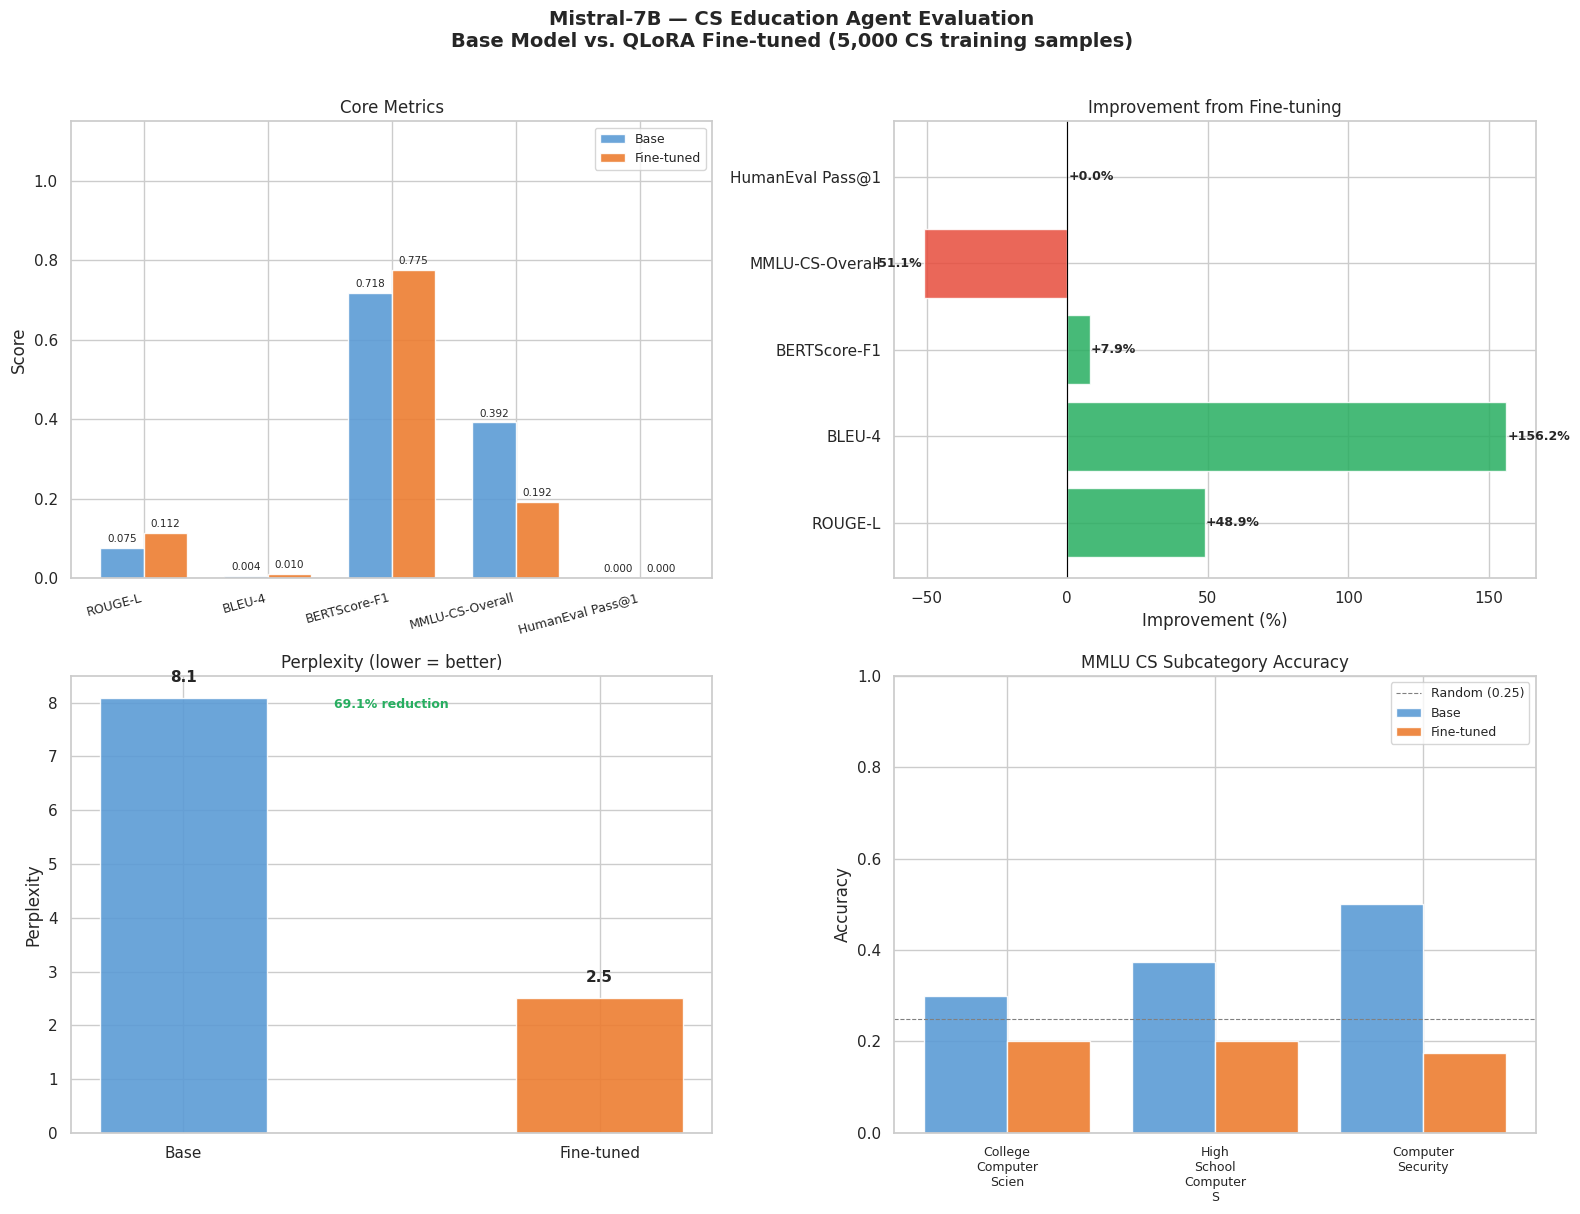

Saved eval_charts.png


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Mistral-7B — CS Education Agent Evaluation\n"
    f"Base Model vs. QLoRA Fine-tuned ({DATASET_SIZE:,} CS training samples)",
    fontsize=14, fontweight="bold", y=1.01,
)

CORE = ["ROUGE-L", "BLEU-4", "BERTScore-F1", "MMLU-CS-Overall", "HumanEval Pass@1"]
CORE = [m for m in CORE if m in eval_results]

# Panel 1: grouped bar
ax1 = axes[0, 0]
x, w = np.arange(len(CORE)), 0.35
b1 = ax1.bar(x-w/2, [eval_results[m]["Base"] for m in CORE], w, label="Base",       color="#5B9BD5", alpha=0.9, edgecolor="white")
b2 = ax1.bar(x+w/2, [eval_results[m]["FT"]   for m in CORE], w, label="Fine-tuned", color="#ED7D31", alpha=0.9, edgecolor="white")
ax1.set_xticks(x); ax1.set_xticklabels(CORE, rotation=15, ha="right", fontsize=9)
ax1.set(ylabel="Score", title="Core Metrics", ylim=(0, 1.15)); ax1.legend(fontsize=9)
for bar in list(b1)+list(b2):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

# Panel 2: improvement %
ax2  = axes[0, 1]
imps = [((eval_results[m]["FT"]-eval_results[m]["Base"])/max(eval_results[m]["Base"],1e-9))*100
        for m in CORE]
hb = ax2.barh(CORE, imps, color=["#27AE60" if v>=0 else "#E74C3C" for v in imps], alpha=0.85, edgecolor="white")
ax2.axvline(0, color="black", lw=0.8)
ax2.set(xlabel="Improvement (%)", title="Improvement from Fine-tuning")
for bar, val in zip(hb, imps):
    ax2.text(val+(0.5 if val>=0 else -0.5), bar.get_y()+bar.get_height()/2,
             f"{val:+.1f}%", ha="left" if val>=0 else "right", va="center", fontsize=9, fontweight="bold")

# Panel 3: perplexity
ax3 = axes[1, 0]
if "Perplexity" in eval_results and eval_results["Perplexity"]["Base"] > 0:
    pv = eval_results["Perplexity"]
    pb = ax3.bar(["Base","Fine-tuned"], [pv["Base"],pv["FT"]],
                 color=["#5B9BD5","#ED7D31"], alpha=0.9, width=0.4, edgecolor="white")
    for bar, val in zip(pb, [pv["Base"], pv["FT"]]):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")
    red = ((pv["Base"]-pv["FT"])/pv["Base"])*100
    ax3.text(0.5, 0.93, f"{red:.1f}% reduction", transform=ax3.transAxes,
             ha="center", fontsize=9, color="#27AE60", fontweight="bold")
    ax3.set(ylabel="Perplexity", title="Perplexity (lower = better)")
else:
    ax3.text(0.5, 0.5, "No perplexity data", ha="center", va="center",
             transform=ax3.transAxes, color="gray")

# Panel 4: MMLU subcategories
ax4      = axes[1, 1]
m_keys   = [k for k in eval_results if k.startswith("MMLU-") and k != "MMLU-CS-Overall"]
if m_keys:
    mx = np.arange(len(m_keys))
    ax4.bar(mx-0.2, [eval_results[k]["Base"] for k in m_keys], 0.4, label="Base",       color="#5B9BD5", alpha=0.9, edgecolor="white")
    ax4.bar(mx+0.2, [eval_results[k]["FT"]   for k in m_keys], 0.4, label="Fine-tuned", color="#ED7D31", alpha=0.9, edgecolor="white")
    ax4.set_xticks(mx); ax4.set_xticklabels([k.replace("MMLU-","").replace(" ","\n") for k in m_keys], fontsize=9)
    ax4.axhline(0.25, color="gray", lw=0.8, ls="--", label="Random (0.25)")
    ax4.set(ylabel="Accuracy", title="MMLU CS Subcategory Accuracy", ylim=(0, 1.0))
    ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eval_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved eval_charts.png")

In [30]:
import zipfile
from google.colab import files

zip_name = "mistral_7b_cs_agent_results.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, fnames in os.walk("results"):
        for fname in fnames:
            fp = os.path.join(root, fname)
            zf.write(fp); print(f"  + {fp}")
    for fname in ["training_curves.png", "eval_charts.png"]:
        if os.path.exists(fname):
            zf.write(fname); print(f"  + {fname}")
    for fname in os.listdir(FINAL_DIR):
        fp = os.path.join(FINAL_DIR, fname)
        if os.path.isfile(fp):
            zf.write(fp, os.path.join("lora_adapters", fname))
            print(f"  + lora_adapters/{fname}")

print(f"\nPackage: {zip_name}")
files.download(zip_name)

  + results/eval_results.json
  + results/eval_summary.csv
  + training_curves.png
  + eval_charts.png
  + lora_adapters/tokenizer_config.json
  + lora_adapters/adapter_model.safetensors
  + lora_adapters/README.md
  + lora_adapters/special_tokens_map.json
  + lora_adapters/adapter_config.json
  + lora_adapters/tokenizer.model
  + lora_adapters/tokenizer.json

Package: mistral_7b_cs_agent_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next Steps

### What you now have
- Fine-tuned Mistral-7B LoRA adapter for CS tutoring (DSA, algorithms, recursion, OOP, debugging)
- 6 evaluation metrics: ROUGE-L, BLEU-4, BERTScore-F1, MMLU-CS, HumanEval Pass@1, P50 Latency
- Results CSV and JSON ready for Workbook 2 sections 4.3 / 4.5 / 6.1

### To resume a stopped run
Just re-run the notebook from Cell 1. Cell 11 automatically finds the latest checkpoint in `./mistral_7b_cs_tutor_lora/` and resumes from there. You never lose more than 50 steps of compute.

### API changes reference (why this notebook is structured this way)
| Issue | Root cause | Fix used |
|---|---|---|
| `libbitsandbytes_cuda128.so` missing | Pinning `bitsandbytes==0.44.1` — no cuda128 binary | Install latest (`--upgrade`) |
| `triton.ops` not found | `bitsandbytes==0.44.1` imports removed triton submodule | Same fix — latest removes that dep |
| `evaluation_strategy` TypeError | Renamed to `eval_strategy` in transformers 4.46 | Use `eval_strategy` |
| `SFTTrainer(tokenizer=...)` TypeError | Renamed to `processing_class` in TRL 0.12 | Use `processing_class=tokenizer` |
| `SFTTrainer(max_seq_length=...)` TypeError | Moved to `SFTConfig` in TRL 0.12 | Pass via `SFTConfig(max_seq_length=...)` |
| `Ministral-3B-Instruct-2410` 404 | That repo does not exist on HuggingFace | Use `Mistral-7B-Instruct-v0.3` |
| Ministral-3-3B-Instruct-2512 crashes | That model is a VLM — has vision encoder | Use pure-text Mistral-7B |